Ball to Ball Dataset Prediction and Classification
1. Runs Prediction in an Over
2. Wicket Prediction in an Over


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score, classification_report,mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix, roc_curve, auc , roc_auc_score, precision_score, recall_score, f1_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [24]:
df = pd.read_csv('../datasets/IPL_BallByBall2008_2024(Updated).csv')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255759 entries, 0 to 255758
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Match id             255759 non-null  int64  
 1   Date                 255759 non-null  object 
 2   Season               255759 non-null  object 
 3   Batting team         255759 non-null  object 
 4   Bowling team         255759 non-null  object 
 5   Innings No           255759 non-null  int64  
 6   Ball No              255759 non-null  float64
 7   Bowler               255759 non-null  object 
 8   Striker              255759 non-null  object 
 9   Non Striker          255759 non-null  object 
 10  runs_scored          255759 non-null  int64  
 11  extras               255759 non-null  int64  
 12  type of extras       13823 non-null   object 
 13  score                255759 non-null  int64  
 14  score/wicket         255759 non-null  object 
 15  wicket_confirmati

Run Prediction 

In [25]:
df["is_extra"] = df["type of extras"].notna().astype(int)  
df["over_number"] = df["Ball No"].astype(int)  
df["ball_in_over"] = (df["Ball No"] - df["Ball No"].astype(int)) * 10  
df["total_runs"] = df["runs_scored"] + df["extras"] 
df["wicket_fallen"] = df["wicket_confirmation"].astype(int)  


categorical_cols = ["Batting team", "Bowling team", "Bowler", "Striker", "Non Striker"]
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


features = ["Batting team", "Bowling team", "Bowler", "Striker", "Non Striker",
            "over_number", "ball_in_over", "is_extra", "wicket_fallen"]
target = "total_runs"

X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.03, 
    max_depth=8, 
    subsample=0.9, 
    colsample_bytree=0.9, 
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)


print("Updated Run Prediction Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")



Updated Run Prediction Results:
Mean Squared Error: 2.4651
Root Mean Squared Error: 1.5701
Mean Absolute Error: 1.1416


Pre Processing The data set 

In [26]:
def preprocess_data(df):
   
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year

    
    df['fielders_involved'].fillna('No_fielder', inplace=True)
    df['type of extras'].fillna('No_extras', inplace=True)
    df['wicket_type'].fillna('No_wicket', inplace=True)
    df['Player Out'].fillna('No_player_out', inplace=True)
    df['wicket_confirmation'].fillna(0, inplace=True)  

    
    categorical_columns = ['Season', 'Batting team', 'Bowling team', 'Bowler', 
                           'Striker', 'Non Striker', 'type of extras', 
                           'wicket_type', 'fielders_involved', 'Player Out']

    df[categorical_columns] = df[categorical_columns].astype(str)

    
    df['Ball No'] = pd.to_numeric(df['Ball No'], errors='coerce')
    df['Innings No'] = pd.to_numeric(df['Innings No'], errors='coerce')

    
    encoders = {}
    for col in categorical_columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
        encoders[col] = le  

    return df, encoders


def prepare_run_features(df):
    features = ['Season_encoded', 'Batting team_encoded', 'Bowling team_encoded',
                'Bowler_encoded', 'Striker_encoded', 'Non Striker_encoded', 
                'month', 'year', 'Ball No', 'Innings No']

    X = df[features]
    y = df['runs_scored']

    return train_test_split(X, y, test_size=0.2, random_state=42)


def prepare_wicket_features(df):
    df['is_wicket'] = df['wicket_confirmation'].astype(int)  

    features = ['Season_encoded', 'Batting team_encoded', 'Bowling team_encoded',
                'Bowler_encoded', 'Striker_encoded', 'Non Striker_encoded', 
                'month', 'year', 'Ball No', 'Innings No']

    X = df[features]
    y = df['is_wicket']

    return train_test_split(X, y, test_size=0.2, random_state=42)


df, encoders = preprocess_data(df)


X_train_runs, X_test_runs, y_train_runs, y_test_runs = prepare_run_features(df)
X_train_wickets, X_test_wickets, y_train_wickets, y_test_wickets = prepare_wicket_features(df)

Handle Imbalance Dataset

Wicket Prediction Based on Balls


Wicket Prediction Results:
Accuracy: 0.8638
ROC-AUC Score: 0.6214


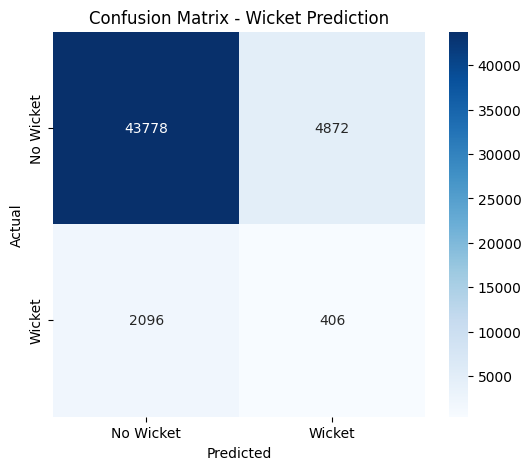

In [27]:
smote = SMOTE(random_state=42)
X_train_wickets_resampled, y_train_wickets_resampled = smote.fit_resample(X_train_wickets, y_train_wickets)


rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_wickets_resampled, y_train_wickets_resampled)


y_pred_probs = rf_model.predict_proba(X_test_wickets)[:, 1]
optimal_threshold = 0.2 
y_pred_wickets = (y_pred_probs >= optimal_threshold).astype(int)


accuracy = accuracy_score(y_test_wickets, y_pred_wickets)
roc_auc = roc_auc_score(y_test_wickets, y_pred_probs)


print("\nWicket Prediction Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


conf_matrix = confusion_matrix(y_test_wickets, y_pred_wickets)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Wicket', 'Wicket'], 
            yticklabels=['No Wicket', 'Wicket'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Wicket Prediction')
plt.show()


ROC-AUC Curve Tracking

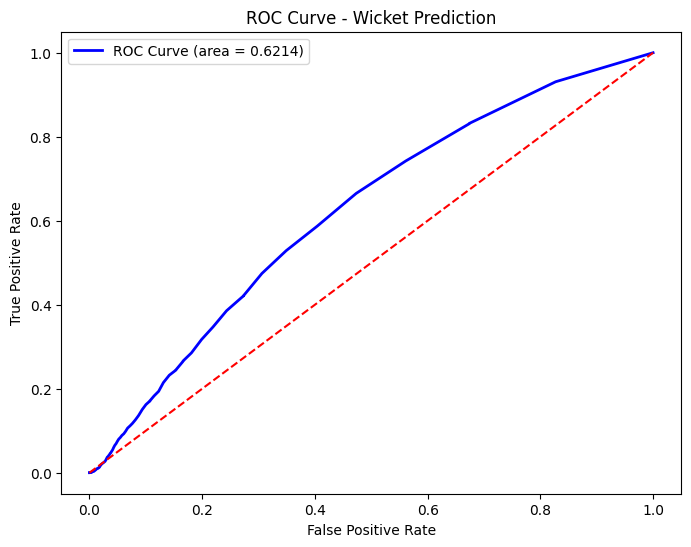

In [28]:
fpr, tpr, _ = roc_curve(y_test_wickets, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Wicket Prediction')
plt.legend()
plt.show()

Save The Models for future Scope

In [ ]:
import os

def save_models(xgb_model, rf_model, encoders):
    save_dir = '../save_models'
    os.makedirs(save_dir, exist_ok=True) 
    
    joblib.dump(xgb_model, f'{save_dir}/run_prediction_model.joblib')
    joblib.dump(rf_model, f'{save_dir}/wicket_prediction_model.joblib')
    joblib.dump(encoders, f'{save_dir}/encoders.joblib')
    
    print("Models and encoders saved successfully!")

save_models(xgb_model, rf_model, encoders)

Models and encoders saved successfully!
